In [ ]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("1_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [ ]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.05, verbose = 1)

Epoch 1/100
11/11 [==============================] - 2s 57ms/step - loss: 1468.4281 - mae: 32.0408 - val_loss: 104.8761 - val_mae: 6.1343
Epoch 2/100
11/11 [==============================] - 0s 9ms/step - loss: 291.9155 - mae: 13.9797 - val_loss: 149.5561 - val_mae: 11.4423
Epoch 3/100
11/11 [==============================] - 0s 7ms/step - loss: 151.9729 - mae: 10.3968 - val_loss: 141.8171 - val_mae: 7.9483
Epoch 4/100
11/11 [==============================] - 0s 8ms/step - loss: 87.9686 - mae: 7.0836 - val_loss: 96.4421 - val_mae: 8.3894
Epoch 5/100
11/11 [==============================] - 0s 10ms/step - loss: 66.2962 - mae: 5.8493 - val_loss: 79.1745 - val_mae: 5.6716
Epoch 6/100
11/11 [==============================] - 0s 13ms/step - loss: 59.8653 - mae: 5.6803 - val_loss: 81.4188 - val_mae: 5.8136
Epoch 7/100
11/11 [==============================] - 0s 7ms/step - loss: 57.8316 - mae: 5.3080 - val_loss: 78.1150 - val_mae: 6.1632
Epoch 8/100
11/11 [==============================] - 0s

In [ ]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 620.2639 - mae: 22.9422 - val_loss: 561.1674 - val_mae: 22.1698
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 617.6243 - mae: 22.9183 - val_loss: 559.4842 - val_mae: 22.1531
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 615.1669 - mae: 22.8962 - val_loss: 557.6986 - val_mae: 22.1374
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 612.6436 - mae: 22.8722 - val_loss: 555.9824 - val_mae: 22.1213
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 610.2982 - mae: 22.8512 - val_loss: 554.3054 - val_mae: 22.1050
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 607.8853 - mae: 22.8305 - val_loss: 552.5520 - val_mae: 22.0893
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 605.3787 - mae: 22.8073 - val_loss: 550.7843 - val_mae: 22.0736
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 602.9745 - mae: 22.7851 - val_loss: 549.1433 - val_mae: 22.0577
Epoch 9/100
21/

In [ ]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 444.8748 - mae: 20.3336
Test Loss (MSE): 444.87481689453125
Test MAE: 20.333616256713867


In [ ]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Actual: 23.60 | Predicted: 5.10
Actual: 32.40 | Predicted: 7.77
Actual: 13.60 | Predicted: -2.57
Actual: 22.80 | Predicted: 4.23
Actual: 16.10 | Predicted: -2.28


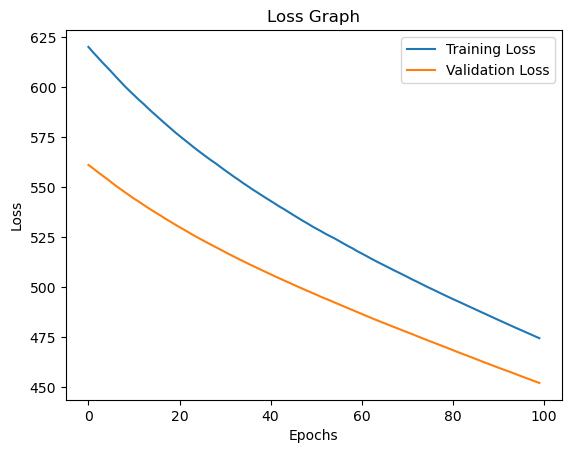

In [ ]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()